In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\2_chains\2_comp
scenario=2comp_equal  K_MODEL=5  K_TRUE=2
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (2, 10000, 5, 4)
  HMC      mu (2, 10000, 5, 4)
  NUTS     mu (2, 10000, 5, 4)
  replication mu (2, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth, Grids (Full + Chebyshev) & Trimmed Mass ──────────
# Two grids per parameter, used by all cells below; the True DGP only enters the
# envelopes and stays an overlay in the plots.
#   "Full"      - min/max envelope over every component of every sampler + True
#                 DGP; nothing excluded, can be very wide.
#   "Chebyshev" - each model's pooled-marginal mean +/- 5*std (exact moments via
#                 the law of total variance), so >= 96% of each model's marginal
#                 mass is guaranteed inside for any distribution.
# Trimmed-mass tables report the realised trim EXACTLY (mixture CDF, no grid
# error) - equal to the renormalisation each density receives in Cell 5. The
# window is symmetric in x, not in mass: the left/right split shows the skew.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

GRIDS = {
    "Full":                  mc.build_grids_full(models, true_model, n_grid=1000, n_sigma=6),
    "Chebyshev (k=5, >=96%)": mc.build_grids_chebyshev(models, true_model, n_grid=1000, k=5.0),
}
for label, grids in GRIDS.items():
    print(f"Grid extents [{label}]:")
    for j, pj in enumerate(param_names):
        print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

for label, grids in GRIDS.items():
    trimmed = {m["name"]: (1.0 - mc.retained_mass(m, grids)) * 100.0
               for m in models + [true_model]}
    print(f"\nMass trimmed by the [{label}] window, in % of each marginal:")
    display(pd.DataFrame(trimmed, index=param_names).T.round(4))

cheb = GRIDS["Chebyshev (k=5, >=96%)"]
split = {}
for m in models + [true_model]:
    l, r = mc.trimmed_tails(m, cheb)
    split[m["name"]] = np.r_[l, r] * 100.0
cols = pd.MultiIndex.from_product([["left tail", "right tail"], param_names])
print("\nChebyshev trim by side, in % of each marginal:")
display(pd.DataFrame(split, index=cols).T.round(4))

Grid extents [Full]:
  Alt1       [-4769.54, +5069.24]
  Alt2       [-1495.26, +1044.47]
  Alt3       [-468.47, +498.61]
  Price      [-452.79, +389.68]
Grid extents [Chebyshev (k=5, >=96%)]:
  Alt1       [-15.78, +20.25]
  Alt2       [-22.02, +23.87]
  Alt3       [-8.37, +12.86]
  Price      [-20.57, +10.68]

Mass trimmed by the [Full] window, in % of each marginal:


,Alt1,Alt2,Alt3,Price
bayesm,0.0,0.0,0.0,0.0
HMC,0.0,0.0,0.0,0.0
NUTS,0.0,0.0,0.0,0.0
replication,0.0,0.0,0.0,0.0
True DGP,0.0,0.0,0.0,0.0



Mass trimmed by the [Chebyshev (k=5, >=96%)] window, in % of each marginal:


,Alt1,Alt2,Alt3,Price
bayesm,0.0368,0.0081,0.0825,0.2339
HMC,0.2321,0.1741,0.2395,0.2939
NUTS,0.3121,0.4015,0.4150,0.0833
replication,0.0156,0.0250,0.0767,0.1167
True DGP,0.0000,0.0000,0.0000,0.0000



Chebyshev trim by side, in % of each marginal:


left tail                         right tail                  \
                 Alt1    Alt2    Alt3   Price       Alt1    Alt2    Alt3   
bayesm         0.0319  0.0034  0.0587  0.2094     0.0048  0.0047  0.0239   
HMC            0.1601  0.0292  0.1641  0.2334     0.0720  0.1449  0.0754   
NUTS           0.2087  0.0301  0.2557  0.0157     0.1034  0.3714  0.1593   
replication    0.0112  0.0029  0.0582  0.0923     0.0043  0.0220  0.0185   
True DGP       0.0000  0.0000  0.0000  0.0000     0.0000  0.0000  0.0000   

                     
              Price  
bayesm       0.0245  
HMC          0.0605  
NUTS         0.0676  
replication  0.0244  
True DGP     0.0000

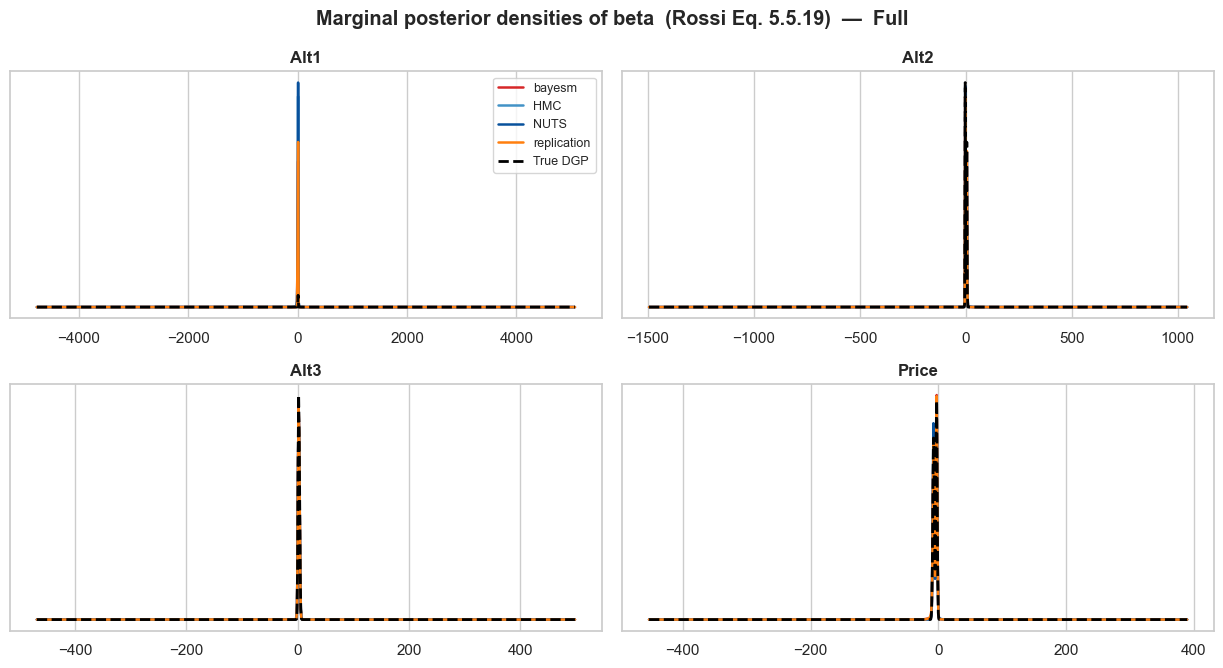

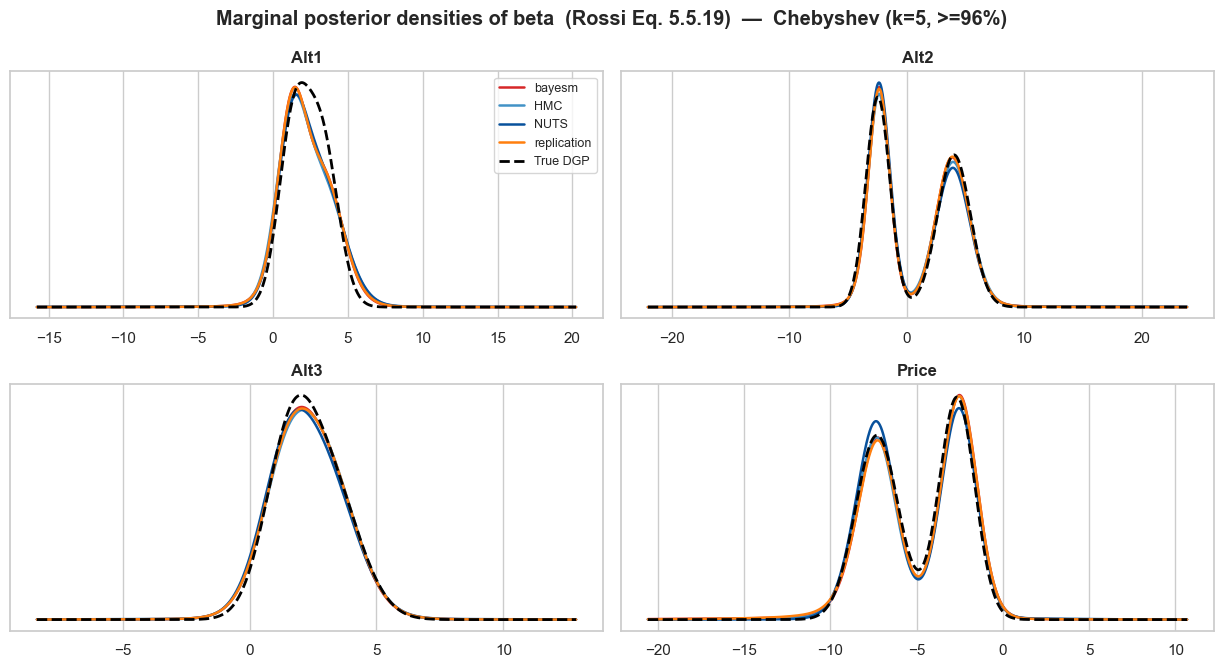

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) - Full vs Chebyshev ──────────
# One figure per grid pass; True DGP dashed black, bayesm red, replication
# orange, Liesel gradient samplers in blues. Densities are cached in
# DENS/DENS_TRUE and reused by Cell 5.
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "bayesm": "#d62728", "replication": "#ff7f0e"}
TRUE_COLOR = "#000000"
ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))

DENS, DENS_TRUE = {}, {}
for label, grids in GRIDS.items():
    dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
    dens_true = mc.marginal_density(true_model, grids)
    DENS[label], DENS_TRUE[label] = dens, dens_true

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
    ax = axes.ravel()
    for j, pj in enumerate(param_names):
        for name, d in dens.items():
            ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
        ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
        ax[j].set_title(pj, fontweight="bold")
        ax[j].set_yticks([])
    for j in range(P, len(ax)):
        ax[j].set_visible(False)
    ax[0].legend(fontsize=9)
    fig.suptitle(f"Marginal posterior densities of beta  (Rossi Eq. 5.5.19)  —  {label}",
                 fontweight="bold")
    fig.tight_layout()
    plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP - Full vs Chebyshev ──────────
# Each sampler vs the True DGP only (never sampler-vs-sampler): Hellinger
# (primary), KL(model||true), JSD, TVD, Wasserstein-1. Reuses DENS/DENS_TRUE.
for label, grids in GRIDS.items():
    print(f"--- {label} ---")
    display(mc.distance_table(models, true_model, grids, param_names,
                               dens=DENS[label], dens_true=DENS_TRUE[label]))

--- Full ---


C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\src\marginal_comparison.py:316: RuntimeWarning: overflow encountered in divide
  term = np.where((a > 0) & (b > 0), a * np.log(a / np.where(b > 0, b, 1.0)), 0.0)


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.23759  2.70235  0.05231  0.24635       2.63573
            Alt2     0.06040      inf  0.00298  0.03750       0.15816
            Alt3     0.05846      inf  0.00288  0.02617       0.09220
            Price    0.09350      inf  0.00692  0.05189       0.24151
HMC         Alt1     0.20209  7.11053  0.03241  0.15421       2.68823
            Alt2     0.06862      inf  0.00366  0.04222       0.24415
            Alt3     0.06777      inf  0.00371  0.03013       0.12450
            Price    0.08574      inf  0.00578  0.04392       0.24230
NUTS        Alt1     0.20498  9.93203  0.03099  0.12760       2.64307
            Alt2     0.08045      inf  0.00481  0.03447       0.30454
            Alt3     0.08100      inf  0.00523  0.04098       0.20195
            Price    0.06643      inf  0.00368  0.04710       0.17583
replication Alt1     0.20413  1.26720  0.03923  0.20656       2.12597
            Alt2     0.05587      inf  0.00256  0.03510       0.15682
            Alt3     0.05797      inf  0.00285  0.02660       0.08357
            Price    0.09237      inf  0.00688  0.05225       0.23011

--- Chebyshev (k=5, >=96%) ---


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.11023  0.14949  0.01116  0.09799       0.26682
            Alt2     0.06838  0.08455  0.00399  0.04422       0.13762
            Alt3     0.05482  0.04011  0.00259  0.02610       0.08027
            Price    0.08707  0.18683  0.00611  0.05012       0.20590
HMC         Alt1     0.12691  0.29380  0.01458  0.10887       0.31772
            Alt2     0.06805  0.15456  0.00385  0.04085       0.15099
            Alt3     0.05829  0.05512  0.00288  0.02824       0.07993
            Price    0.07674  0.14126  0.00477  0.04182       0.18398
NUTS        Alt1     0.12419  0.35650  0.01364  0.09635       0.29638
            Alt2     0.07213  0.25553  0.00415  0.04820       0.19395
            Alt3     0.06703  0.07472  0.00380  0.03879       0.12580
            Price    0.06324  0.09185  0.00339  0.04653       0.16058
replication Alt1     0.11221  0.13892  0.01154  0.09846       0.26679
            Alt2     0.06277  0.07843  0.00339  0.04118       0.13467
            Alt3     0.05456  0.03925  0.00258  0.02638       0.07287
            Price    0.08918  0.16142  0.00648  0.05133       0.20484

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
# Grid-independent (analytic in the draws); runs once.
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.196,2.163,2.232,2.217,2.307
Alt2,0.881,0.945,0.923,0.892,0.791
Alt3,2.286,2.289,2.243,2.298,2.357
Price,-4.952,-4.947,-4.989,-4.952,-4.978


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,3.326,10.505,12.835,3.136,1.982
Alt2,12.330,16.299,20.948,12.402,12.009
Alt3,2.390,3.338,4.468,2.379,1.840
Price,9.208,9.702,8.077,9.048,6.678


In [7]:
# ── Cell 7 : Convergence of the Marginals - Goose-identical functional diagnostics ──────────
# az.rhat (rank) / az.ess (bulk, tail) - the exact calls in Goose's summary() -
# on grid-free functionals of each per-draw marginal: mean, sd, q05/q50/q95.
# ESS/s divides by the fit's total wall-clock (meta.json duration_s, incl.
# warmup). Read ESS only where R-hat ~ 1. Alternatives: mc.curve_diagnostics,
# mc.density_series_diagnostics.
if CHAINS == 1:
    print("NOTE: single chain -> split-chain diagnostics; WITHIN-chain checks only.\n")

for m in models:
    rt = m.get("duration_s")
    print(f"--- {m['name']}" + (f"  (fit wall-clock: {rt:,.0f}s)" if rt else "") + " ---")
    display(mc.functional_diagnostics(m, param_names).round(3))

--- bayesm  (fit wall-clock: 419s) ---


Rhat   ESS_bulk   ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                     
Alt1  mean        1.011    431.824    608.693       1.031       1.453
      sd          1.006    180.334    100.809       0.430       0.241
      q05         1.011    381.240   1539.664       0.910       3.675
      q50         1.004   1357.996   4446.594       3.241      10.612
      q95         1.009    447.882   1108.998       1.069       2.647
Alt2  mean        1.004    786.939   5431.612       1.878      12.963
      sd          1.010    241.321    751.493       0.576       1.794
      q05         1.012    179.083    374.173       0.427       0.893
      q50         1.000  11991.735  12936.154      28.620      30.874
      q95         1.003    627.183   1277.072       1.497       3.048
Alt3  mean        1.010    819.772   2222.371       1.956       5.304
      sd          1.002    599.558   1087.575       1.431       2.596
      q05         1.003    862.682   2047.866       2.059       4.888
      q50         1.003   1263.990   3986.959       3.017       9.515
      q95         1.004    826.362   2009.703       1.972       4.796
Price mean        1.032     63.633     95.584       0.152       0.228
      sd          1.080     25.950     45.946       0.062       0.110
      q05         1.009    132.389    231.431       0.316       0.552
      q50         1.001   6198.367   9261.065      14.793      22.103
      q95         1.000   5976.959  13301.549      14.265      31.746

--- HMC  (fit wall-clock: 435s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.059    28.725    27.407       0.066       0.063
      sd          1.051    34.941    22.040       0.080       0.051
      q05         1.008   161.176   560.943       0.371       1.291
      q50         1.018   186.284   998.812       0.429       2.298
      q95         1.020    95.619   185.977       0.220       0.428
Alt2  mean        1.016   131.381   232.686       0.302       0.535
      sd          1.029    47.519   101.558       0.109       0.234
      q05         1.006   162.333   560.897       0.374       1.291
      q50         1.000  5831.366  5946.144      13.418      13.682
      q95         1.005   197.681   550.401       0.455       1.266
Alt3  mean        1.029   218.645   584.415       0.503       1.345
      sd          1.016   126.458   464.799       0.291       1.069
      q05         1.005   397.934   709.197       0.916       1.632
      q50         1.016   241.469   532.829       0.556       1.226
      q95         1.009   211.061   659.188       0.486       1.517
Price mean        1.082    21.328   119.646       0.049       0.275
      sd          1.170     9.398    22.930       0.022       0.053
      q05         1.029    43.066    23.591       0.099       0.054
      q50         1.002  2433.218  3279.100       5.599       7.545
      q95         1.036    38.567   538.495       0.089       1.239

--- NUTS  (fit wall-clock: 3,722s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.068    56.619    87.340       0.015       0.023
      sd          1.033    94.948   111.717       0.026       0.030
      q05         1.004   199.570   370.715       0.054       0.100
      q50         1.172     8.334    72.552       0.002       0.019
      q95         1.106    15.619   246.018       0.004       0.066
Alt2  mean        1.039   117.669   296.893       0.032       0.080
      sd          1.067    28.743   183.147       0.008       0.049
      q05         1.024   227.890   574.671       0.061       0.154
      q50         1.443     3.944    45.963       0.001       0.012
      q95         1.006   419.477  1220.363       0.113       0.328
Alt3  mean        1.016   154.517   200.600       0.042       0.054
      sd          1.006   344.656   570.903       0.093       0.153
      q05         1.008   398.254  1404.277       0.107       0.377
      q50         1.033   105.857   470.917       0.028       0.127
      q95         1.017   197.620   901.404       0.053       0.242
Price mean        1.297     5.299    55.389       0.001       0.015
      sd          1.008   256.398   955.991       0.069       0.257
      q05         1.026   186.814   475.676       0.050       0.128
      q50         1.505     3.669    38.520       0.001       0.010
      q95         1.021   297.183  1457.645       0.080       0.392

--- replication  (fit wall-clock: 318s) ---


Rhat   ESS_bulk   ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                     
Alt1  mean        1.001   1019.174   3140.659       3.208       9.886
      sd          1.007    572.510   2164.806       1.802       6.814
      q05         1.019    389.205   1139.619       1.225       3.587
      q50         1.000   1116.871   4173.634       3.515      13.137
      q95         1.007    268.587    200.653       0.845       0.632
Alt2  mean        1.017    141.391    603.051       0.445       1.898
      sd          1.015    186.939     85.188       0.588       0.268
      q05         1.019    166.655    512.067       0.525       1.612
      q50         1.000  11014.619  12338.224      34.670      38.836
      q95         1.007    573.537   1101.432       1.805       3.467
Alt3  mean        1.006    589.417   2005.312       1.855       6.312
      sd          1.009    822.397   1404.339       2.589       4.420
      q05         1.003    999.594   2366.248       3.146       7.448
      q50         1.006   1055.288   3814.462       3.322      12.006
      q95         1.004    697.580   1441.634       2.196       4.538
Price mean        1.018    164.691    231.156       0.518       0.728
      sd          1.050     61.763     89.098       0.194       0.280
      q05         1.045     76.987    329.446       0.242       1.037
      q50         1.001   5174.992   9719.903      16.289      30.595
      q95         1.001   3209.614  11247.362      10.103      35.402

In [8]:
# ── Cell 8 : Notes ──────────
print("Notes:")
print(" - All quantities are label-invariant: relabeling/ECR would not change them.")
print(" - Grids: 'Full' = unbounded envelope over every component + True DGP;")
print("   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).")
print(" - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail")
print("   ESS) on grid-free functionals of each per-draw marginal.")
print(" - 1-chain runs: chains split into halves - a within-chain check only.")
print("   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).")

Notes:
 - All quantities are label-invariant: relabeling/ECR would not change them.
 - Grids: 'Full' = unbounded envelope over every component + True DGP;
   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).
 - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail
   ESS) on grid-free functionals of each per-draw marginal.
 - 1-chain runs: chains split into halves - a within-chain check only.
   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).
